In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image

In [3]:
# 解除 Pillow 大图像限制
Image.MAX_IMAGE_PIXELS = None

### 真实标签标注

In [3]:
def merge_labels_to_csv(csv_path, npy_path, output_path):
    # 1. 加载数据
    df = pd.read_csv(csv_path)
    label_map = np.load(npy_path)
    h_map, w_map = label_map.shape

    # 2. 定义符合你图片及文字描述的字典
    # 注意：为了方便神经网络训练，我们通常把背景统一，或在训练时跳过
    mineral_map = {
        -1: "背景 (Background)",
        0: "黄铁矿 (Pyrite)",
        1: "闪锌矿 (Sphalerite)",
        2: "方铅矿 (Galena)",
        3: "方解石 (Calcite)",
        4: "石英 (Quartz)"
    }

    gt_labels = []
    for _, row in df.iterrows():
        # 坐标采样
        ix = int(row['state_cx'] * (w_map - 1))
        iy = int(row['state_cy'] * (h_map - 1))

        mineral_class = int(label_map[iy, ix])
        gt_labels.append(mineral_class)

    # 3. 写入原始数值
    df['gt_label_idx'] = gt_labels
    # 4. 映射中文名称
    df['mineral_name'] = df['gt_label_idx'].map(mineral_map)

    # 如果颗粒质心落在 -1（背景）上，说明分割不准或该点确实是基质
    # 在强化学习训练集中，我们通常只保留真正的矿物颗粒
    df_filtered = df[df['gt_label_idx'] != -1].copy()

    # 5. 保存结果
    df_filtered.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"处理完成！原始样本 {len(df)}个，剔除背景后剩余有效矿物颗粒 {len(df_filtered)}个。")
    print(f"数据已保存至: {output_path}")

In [4]:

# 调用
merge_labels_to_csv('./output/mineral_states_for_rl.csv', './data/L-Z-3-1.npy', './output/mineral_train_set.csv')

处理完成！原始样本 430个，剔除背景后剩余有效矿物颗粒 402个。
数据已保存至: ./output/mineral_train_set.csv


### 各类矿物面积占比

In [5]:
# ---------- 中文字体 ----------
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [6]:
# ---------- 路径 ----------
ANNOTATED_CSV = "./output/mineral_train_set.csv"
LABEL_NPY     = "./data/L-Z-3-1.npy"
OUTPUT_DIR    = "./output"

组合饼图已保存至: ./output/dual_pie_comparison.png


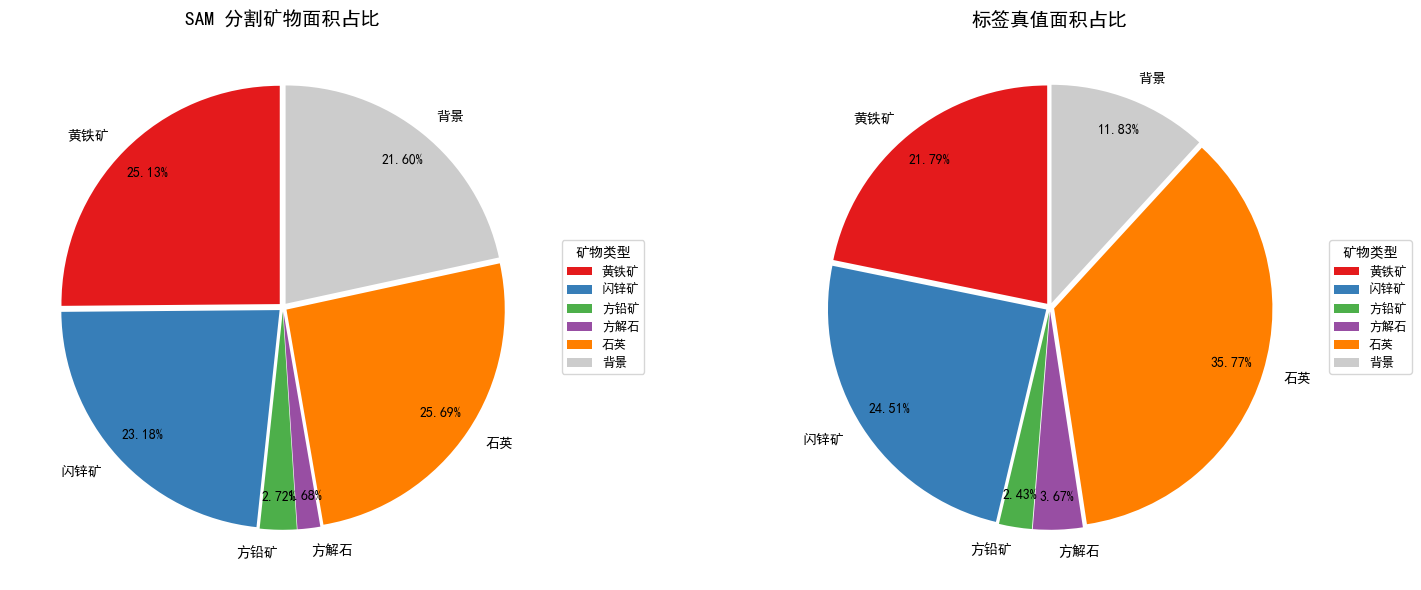

In [7]:
# 矿物信息
MINERAL_ORDER = [0, 1, 2, 3, 4]
MINERAL_NAMES = {0:"黄铁矿",1:"闪锌矿",2:"方铅矿",3:"方解石",4:"石英",-1:"背景"}
COLORS = {0:'#e41a1c',1:'#377eb8',2:'#4daf4a',3:'#984ea3',4:'#ff7f00',-1:'#cccccc'}

# ========== 1. SAM分割面积占比（基于标注后的CSV） ==========
df_sam = pd.read_csv(ANNOTATED_CSV)
area_sam = df_sam.groupby('gt_label_idx')['state_area_ratio'].sum()
total_mineral = area_sam.sum()
back_sam = 1.0 - total_mineral
sizes_sam = [area_sam.get(c, 0) for c in MINERAL_ORDER] + [back_sam]
labels_sam = [MINERAL_NAMES[c] for c in MINERAL_ORDER] + ["背景"]
colors_sam = [COLORS[c] for c in MINERAL_ORDER] + [COLORS[-1]]

# ========== 2. 标签文件真值面积占比（像素统计） ==========
label_map = np.load(LABEL_NPY)
total_pixels = label_map.size
sizes_gt = [np.sum(label_map == c)/total_pixels for c in MINERAL_ORDER] + \
           [np.sum(label_map == -1)/total_pixels]
labels_gt = [MINERAL_NAMES[c] for c in MINERAL_ORDER] + ["背景"]
colors_gt = [COLORS[c] for c in MINERAL_ORDER] + [COLORS[-1]]

# ---------- 绘制并列饼图 ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))   # 适当加宽画布

# 左图：SAM 分割
wedges1, texts1, autotexts1 = axes[0].pie(
    sizes_sam, labels=labels_sam, autopct='%1.2f%%',
    startangle=90, colors=colors_sam,
    explode=[0.02]*len(sizes_sam), pctdistance=0.85
)
axes[0].set_title("SAM 分割矿物面积占比", fontsize=14)
# 图例移至右侧外侧
axes[0].legend(wedges1, labels_sam, title="矿物类型",
               loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)

# 右图：标签真值
wedges2, texts2, autotexts2 = axes[1].pie(
    sizes_gt, labels=labels_gt, autopct='%1.2f%%',
    startangle=90, colors=colors_gt,
    explode=[0.02]*len(sizes_gt), pctdistance=0.85
)
axes[1].set_title("标签真值面积占比", fontsize=14)
axes[1].legend(wedges2, labels_gt, title="矿物类型",
               loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)

plt.tight_layout()
# 保存
save_path = f"{OUTPUT_DIR}/dual_pie_comparison.png"
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"组合饼图已保存至: {save_path}")
# 在Jupyter中显示
plt.show()

### 原始图像、分割图像和带真实标签图像对比图

对比图已保存至 ./output/comparison_heatmap.png


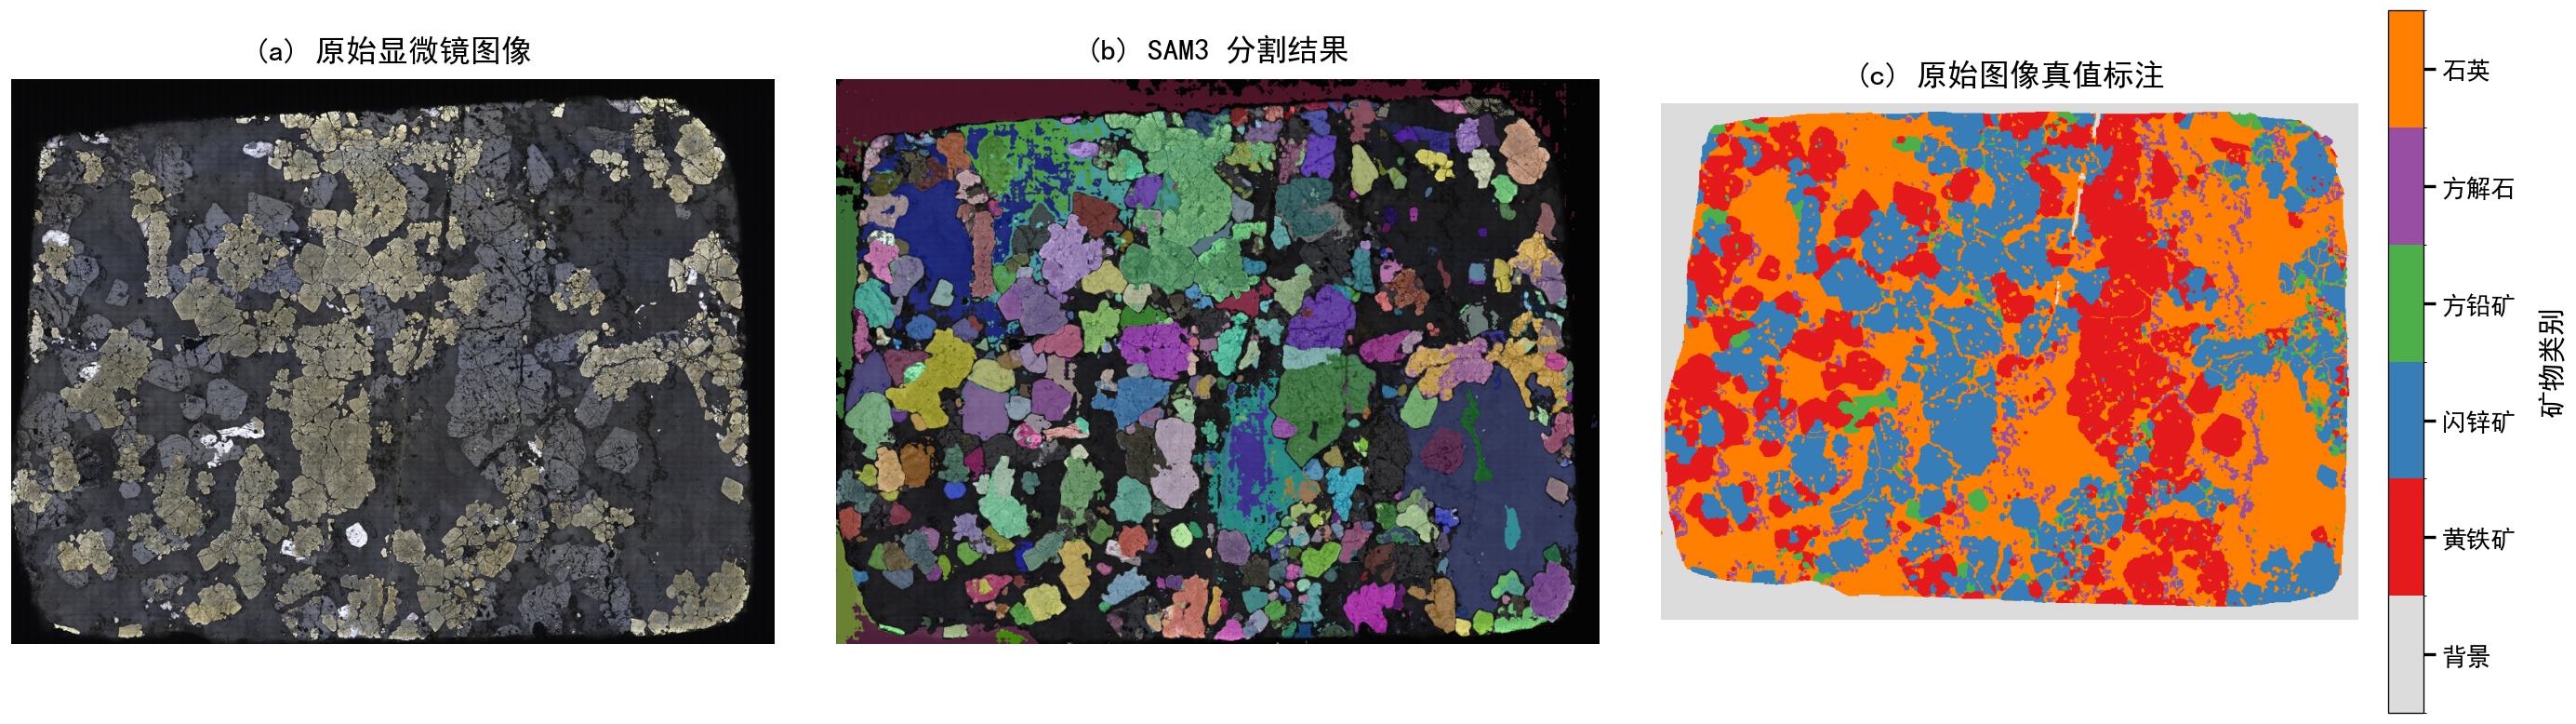

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from PIL import Image
import cv2

# ========== 全局字体设置（清晰度优先，兼容所有版本） ==========
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams.update({
    'font.size': 16,           # 基础字号
    'axes.titlesize': 20,      # 增大子图标题字号
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.dpi': 120,         # 提高屏幕显示清晰度
    'savefig.dpi': 600,        # 大幅提高输出分辨率，满足论文印刷要求
    'font.weight': 'normal'
})

# ========== 文件路径配置 ==========
ORIG_IMG  = "./data/img_mosaic_big.jpg"
SEG_IMG   = "./output/final_mineral_rl_view.jpg"
LABEL_NPY = "./data/L-Z-3-1.npy"
SAVE_PATH = "./output/comparison_heatmap.png"

# 矿物颜色映射 (RGB 0‑255) —— 与之前饼图颜色一致，保证论文前后统一
COLORS_RGB = {
    -1: (220, 220, 220),  # 背景
     0: (228, 26, 28),    # 黄铁矿
     1: (55, 126, 184),   # 闪锌矿
     2: (77, 175, 74),    # 方铅矿
     3: (152, 78, 163),   # 方解石
     4: (255, 127, 0)     # 石英
}
MINERAL_NAMES = {
    -1: "背景", 0: "黄铁矿", 1: "闪锌矿", 2: "方铅矿", 3: "方解石", 4: "石英"
}

# ========== 创建自定义颜色映射和归一化器 ==========
category_order = [-1, 0, 1, 2, 3, 4]
colors_norm = [tuple(c/255 for c in COLORS_RGB[cls]) for cls in category_order]
custom_cmap = ListedColormap(colors_norm)
bounds = [-1.5, -0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
custom_norm = BoundaryNorm(bounds, custom_cmap.N)

# ========== 1. 加载并缩放原始图像 ==========
pil_orig = Image.open(ORIG_IMG)
TARGET_W = 1000
scale = TARGET_W / pil_orig.width
TARGET_H = int(pil_orig.height * scale)
orig_arr = np.array(pil_orig.resize((TARGET_W, TARGET_H), Image.LANCZOS))

# ========== 2. 加载并缩放 SAM 分割图 ==========
seg_bgr = cv2.imread(SEG_IMG)
if seg_bgr is not None:
    seg_arr = cv2.cvtColor(seg_bgr, cv2.COLOR_BGR2RGB)
    seg_arr = cv2.resize(seg_arr, (TARGET_W, TARGET_H), interpolation=cv2.INTER_LINEAR)
else:
    seg_arr = np.zeros((TARGET_H, TARGET_W, 3), dtype=np.uint8)

# ========== 3. 加载并缩放真实标签（保留标量值） ==========
label_map = np.load(LABEL_NPY)
label_resized_scalar = cv2.resize(label_map, (TARGET_W, TARGET_H), interpolation=cv2.INTER_NEAREST)

# ========== 4. 绘制三图对比 ==========
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# 4a. 原始图像
axes[0].imshow(orig_arr)
axes[0].set_title('(a) 原始显微镜图像', fontweight='bold', pad=12)
axes[0].axis('off')

# 4b. SAM 分割结果
axes[1].imshow(seg_arr)
axes[1].set_title('(b) SAM3 分割结果', fontweight='bold', pad=12)
axes[1].axis('off')

# 4c. 原始图像真值标注（带正确颜色条）
im = axes[2].imshow(label_resized_scalar, cmap=custom_cmap, norm=custom_norm)
axes[2].set_title('(c) 原始图像真值标注', fontweight='bold', pad=12)
axes[2].axis('off')

# ========== 完全修复的颜色条配置 ==========
cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, ticks=category_order)
cbar.ax.set_yticklabels([MINERAL_NAMES[t] for t in category_order], fontsize=16, fontweight='bold')
cbar.set_label('矿物类别', fontsize=18, fontweight='bold', labelpad=15)
cbar.ax.tick_params(length=8, width=2)

plt.tight_layout(pad=2.5)
# 修复：将这两个参数移到savefig函数中单独传入
plt.savefig(SAVE_PATH, bbox_inches='tight', pad_inches=0.2)
print(f"对比图已保存至 {SAVE_PATH}")
plt.show()